<a href="https://colab.research.google.com/github/mfletcher2021/blogcode/blob/main/NBA_26_27_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing necessary packages

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression

Importing the dataset into Python

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NBA analysis 2026-27.xlsx to NBA analysis 2026-27.xlsx


In [ ]:
import io

NBA = pd.read_excel(io.BytesIO(uploaded['NBA analysis 2026-27.xlsx']))

Reading the dataset

In [ ]:
NBA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Season  300 non-null    object 
 1   Team    300 non-null    object 
 2   W       300 non-null    int64  
 3   L       300 non-null    int64  
 4   Finish  300 non-null    int64  
 5   Age     300 non-null    float64
 6   Ht.     300 non-null    object 
 7   Wt.     300 non-null    int64  
 8   G       300 non-null    int64  
 9   MP      300 non-null    int64  
 10  FG      300 non-null    int64  
 11  FGA     300 non-null    int64  
 12  FG%     300 non-null    float64
 13  3P      300 non-null    int64  
 14  3PA     300 non-null    int64  
 15  3P%     300 non-null    float64
 16  2P      300 non-null    int64  
 17  2PA     300 non-null    int64  
 18  2P%     300 non-null    float64
 19  FT      300 non-null    int64  
 20  FTA     300 non-null    int64  
 21  FT%     300 non-null    float64
 22  OR

In [ ]:
NBA.head()

,Season,Team,W,L,Finish,Age,Ht.,Wt.,G,MP,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,WT
0,2016-17,Atlanta Hawks,43,39,5,27.9,6'6,219,82,19880,...,842,2793,3635,1938,672,397,1294,1491,8459,0.025
1,2017-18,Atlanta Hawks,24,58,15,25.4,6'6,212,82,19705,...,743,2693,3436,1946,638,348,1275,1606,8475,0.025
2,2018-19,Atlanta Hawks,29,53,12,25.1,6'6,213,82,19855,...,955,2825,3780,2118,675,419,1397,1932,9294,0.025
3,2019-20,Atlanta Hawks,20,47,14,24.1,6'6,213,67,16280,...,661,2237,2898,1605,523,341,1086,1548,7488,0.025
4,2020-21,Atlanta Hawks,41,31,5,25.4,6'6,212,72,17405,...,760,2525,3285,1737,503,342,953,1392,8186,0.100


Performing the train, test, split-linear regression style

In [ ]:
X = NBA[['FG%', '3P%', '2P%', 'Finish', 'TRB', 'AST', 'STL', 'BLK', 'TOV']]
y = NBA['W']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

Making the model

In [ ]:
NBAMODEL = LinearRegression()
NBAMODEL.fit(X_train, y_train)

LinearRegression()

In [ ]:
yPredictions = NBAMODEL.predict(X_test)

yPredictions

array([65.07869246, 26.72012009, 52.0477539 , 53.47996102, 44.77159359,
       42.38632321, 24.50093722, 38.02235669, 24.12764734, 58.05939653,
       50.10300323, 55.21172268, 32.06842078, 31.00517531, 43.05700496,
       50.49176704, 54.14854293, 60.56930431, 44.68495799, 55.61211228,
       30.65036575, 46.32708907, 50.16604161, 40.84213077, 52.76997511,
       32.09917264, 47.86779029, 31.34745932, 51.22309195, 29.25967716,
       59.88057863, 32.76439688, 40.73391088, 42.87839716, 39.47062069,
       38.39770244, 40.67789209, 31.09947476, 23.71976299, 43.55969316,
       42.93678958, 60.64355209, 38.76606644, 31.07464148, 37.54562701,
       50.42009358, 48.77375108, 43.30361315, 37.55985083, 45.17318334,
       47.28641487, 35.77845195, 18.63720427, 25.87962965, 52.1765097 ,
       27.2568848 , 50.79982717, 44.39331897, 56.82528487, 43.97914127])

Finding the coefficients and intercepts of the regression model equation

In [ ]:
NBAMODEL.coef_

array([ 2.71506641e+01,  1.05762953e+02,  4.79314144e+01, -2.01219789e+00,
        1.26615342e-02, -5.15358323e-03,  2.13508982e-02,  1.82350811e-03,
       -1.08085621e-02])

In [ ]:
NBAMODEL.intercept_

np.float64(-56.03481183753681)

Evaluating model's accuracy

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y_test,yPredictions)

0.07401438823215295

Viewing results of predictions on a scatterplot

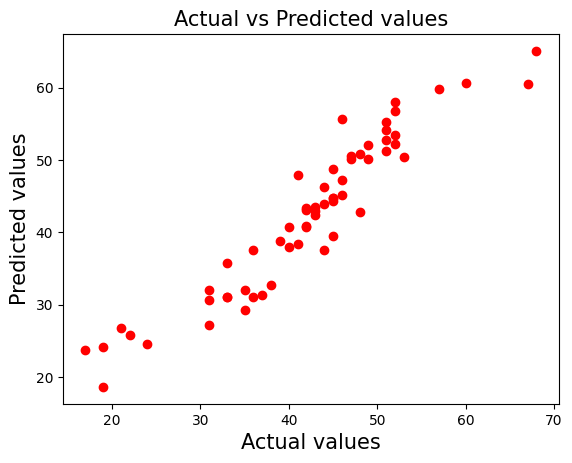

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, yPredictions, color="red")
plt.xlabel('Actual values', size=15)
plt.ylabel('Predicted values', size=15)
plt.title('Actual vs Predicted values', size=15)
plt.show()